# DSC530 Final Project

## 1. Data Selection

For this project, I selected the **New York City Airbnb Open Data (2019)** dataset, which provides a comprehensive snapshot of Airbnb listings across New York’s boroughs. It includes over 48,000 records with variables such as listing ID, host information, geographic coordinates, price, minimum nights, number of reviews, availability, and room type.

The dataset is publicly available and obtained from:

[Kaggle NYC Airbnb](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)

and the original source can be found on:

**[Inside Airbnb](https://insideairbnb.com/)**  
> “The data behind the Inside Airbnb site is sourced from publicly available information from the Airbnb site. The data has been analyzed, cleansed and aggregated to facilitate public discussion.”

The dataset contains detailed information that enables rich exploratory analysis, including:
- Host and listing identification
- Location (latitude and longitude)
- Borough/neighborhood
- Room type (e.g., entire home, private room)
- Price and availability
- Review count and activity

This dataset:
- Is large and diverse enough to support advanced statistical and machine learning techniques.
- Contains a mix of numerical and categorical variables suitable for thorough EDA.
- Comes from a trusted and transparent source with clearly documented context.


## 2. Data Cleaning and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the dataset
df = pd.read_csv('AB_NYC_2019.csv.zip')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
# initial inspection
print(df.shape)
print(df.info())

(48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review         

In [4]:
# check for missing values
missing = df.isnull().sum()
print(missing)

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [5]:
# drop columns with unnecessary info or with many missing values: name, host_name, last_review
df = df.drop(columns=["name","host_name","last_review"])

In [6]:
# replace missing values with 0 for reviews per month with missing values
df["reviews_per_month"].fillna(0,inplace=True)

In [7]:
# removing obvious outliers that doesn't give much information
# listings with too high prices and unrealistic minimum nights
df = df[df["price"] <= 1000]
df = df[df["minimum_nights"] <= 100]


Text(0.5, 1.0, 'Distribution of Number_of_Reviews')

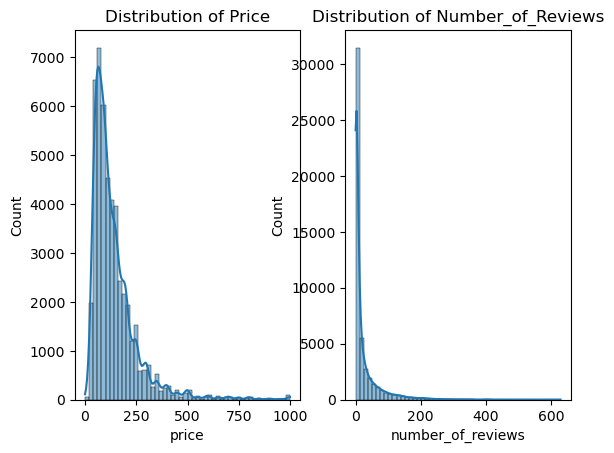

In [8]:
# look at the distributions of variables and decide whether to transform the data
# price
plt.subplot(1,2,1)
sns.histplot(df["price"], bins = 50, kde=True)
plt.title('Distribution of Price')

# number of reviews
plt.subplot(1,2,2)
sns.histplot(df["number_of_reviews"], bins = 50, kde=True)
plt.title('Distribution of Number_of_Reviews')

Text(0.5, 1.0, 'Distribution of availability_365')

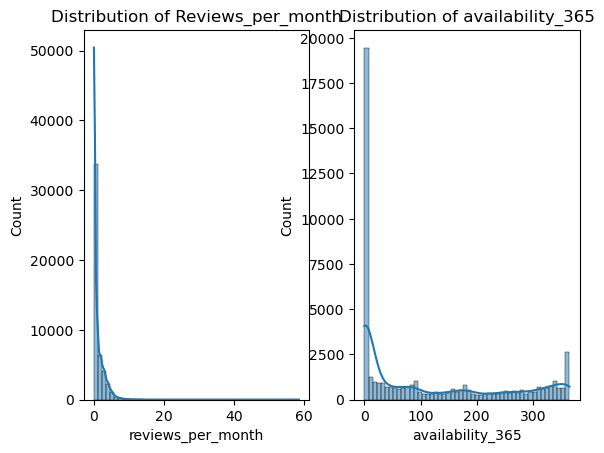

In [9]:
#reviews per month
plt.subplot(1,2,1)
sns.histplot(df['reviews_per_month'], bins=50, kde=True)
plt.title('Distribution of Reviews_per_month')

#availability_365
plt.subplot(1,2,2)
sns.histplot(df['availability_365'], bins=50, kde=True)
plt.title('Distribution of availability_365')

Text(0.5, 1.0, 'Distribution of calculated_host_listings_count')

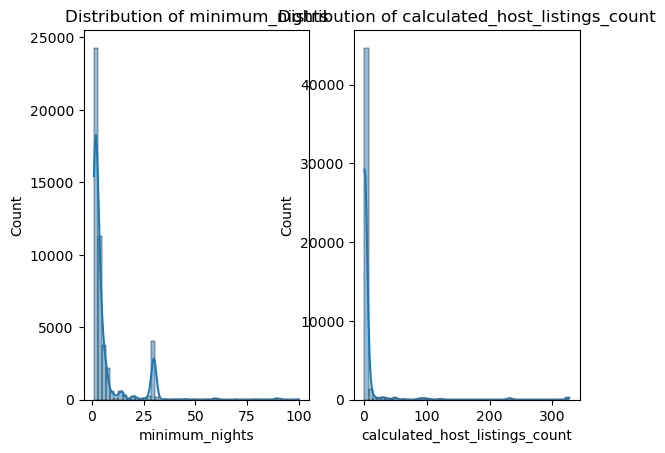

In [10]:
#minimum_nights
plt.subplot(1,2,1)
sns.histplot(df['minimum_nights'], bins=50, kde=True)
plt.title('Distribution of minimum_nights')

#calculated_host_listings_count
plt.subplot(1,2,2)
sns.histplot(df['calculated_host_listings_count'], bins=50, kde=True)
plt.title('Distribution of calculated_host_listings_count')

### Transformations

Before applying any transformations, I examined the distribution of key numeric variables using histograms. This step helps determine whether variables are heavily skewed and if transformations are required.

transformations:
- `price`: Strong right skew; apply log transformation.
- `minimum_nights`: Contains extreme values; cap at 50.
- `number_of_reviews`: Right skew; apply log transformation.
- `reviews_per_month`: Right skew with many listings having 0 reviews; apply log transformation.
- `calculated_host_listings_count`: Many listings with only 1 listing; apply log transformation.
- `availability_365`: Bimodal distribution; no transformation applied.

In [11]:
# cap minimum_nights to 50
df['minimum_nights_capped'] = df['minimum_nights'].clip(upper=50)

#log transformations
df['log_price'] = np.log1p(df['price'])
df['log_number_of_reviews'] = np.log1p(df['number_of_reviews'])
df['log_reviews_per_month'] = np.log1p(df['reviews_per_month'])
df['log_host_listings_count'] = np.log1p(df['calculated_host_listings_count'])

## 3. Data Descriptions

Below is a description of the variables included in the dataset used for this analysis.
- `id`: Numerical – Unique identifier for each listing.
- `host_id`: Numerical – Unique identifier for each host.
- `neighbourhood_group`: Categorical – Borough in NYC where the listing is located.
- `neighbourhood`: Categorical – Specific neighborhood within the borough.
- `latitude`: Numerical – Geographic latitude of the listing.
- `longitude`: Numerical – Geographic longitude of the listing.
- `room_type`: Categorical – Type of rental.
- `price`: Numerical – Nightly cost of the listing.
- `minimum_nights`: Numerical – Minimum number of nights required to book.
- `number_of_reviews`: Numerical – Total number of reviews received.
- `reviews_per_month`: Numerical – Average number of reviews per month.
- `calculated_host_listings_count`: Numerical – Total number of listings managed by the host.
- `availability_365`: Numerical – Number of days in a year the listing is available.

- `price`, `number_of_reviews`, `reviews_per_month`, and `calculated_host_listings_count` were log-transformed using the logarithm to normalize their distributions and reduce the impact of outliers.
- `minimum_nights` was capped at 50 nights to reduce the influence of outliers


## 4. Univariate Analysis

Visualizations of key variables are done in the previous section and transformations are applied accordingly. In this section, I will focus on distributions after the transformations and their desriptive statistics.

In [12]:
#decriptive statistics for key variables
# numeric columns:
numeric = [
    'log_price',
    'minimum_nights_capped',
    'log_number_of_reviews',
    'log_reviews_per_month',
    'log_host_listings_count',
    'availability_365'
]

# get descriptive stats
stats = df[numeric].describe().T
stats["skew"] = df[numeric].skew()
stats["kurtosis"] = df[numeric].kurtosis()

print(stats)

                           count        mean         std       min       25%  \
log_price                48491.0    4.722506    0.665650  0.000000  4.248495   
minimum_nights_capped    48491.0    5.992473    9.068792  1.000000  1.000000   
log_number_of_reviews    48491.0    1.998843    1.563521  0.000000  0.693147   
log_reviews_per_month    48491.0    0.545644    0.578467  0.000000  0.039221   
log_host_listings_count  48491.0    1.087427    0.859431  0.693147  0.693147   
availability_365         48491.0  112.089790  131.247854  0.000000  0.000000   

                               50%         75%         max      skew  \
log_price                 4.663439    5.170484    6.908755  0.246711   
minimum_nights_capped     2.000000    5.000000   50.000000  2.444782   
log_number_of_reviews     1.791759    3.218876    6.445720  0.358296   
log_reviews_per_month     0.322083    0.955511    4.085976  0.942434   
log_host_listings_count   0.693147    1.098612    5.793014  3.282599   
availab

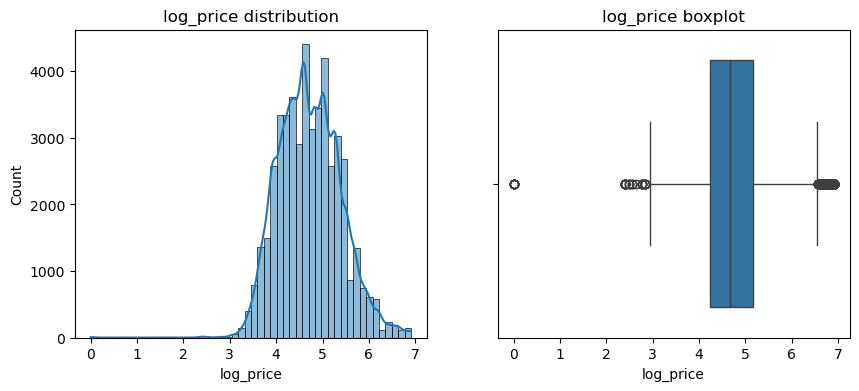

In [13]:
# Visualizations
#log price
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sns.histplot(df['log_price'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('log_price distribution')

sns.boxplot(x=df['log_price'], ax=axes[1])
axes[1].set_title('log_price boxplot')

plt.show()

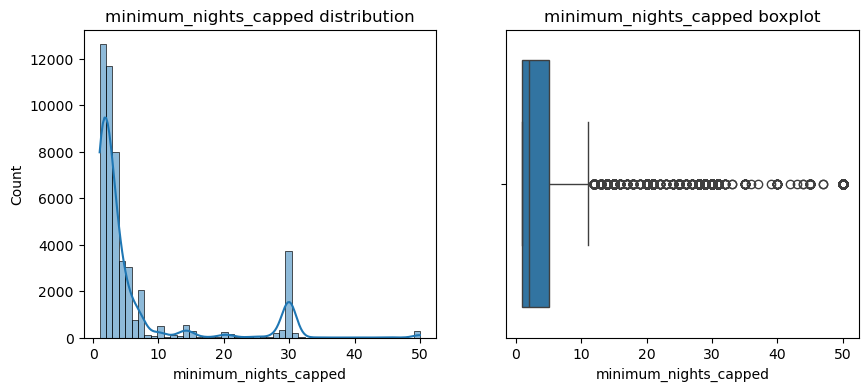

In [14]:
#minimum nights capped
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sns.histplot(df['minimum_nights_capped'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('minimum_nights_capped distribution')

sns.boxplot(x=df['minimum_nights_capped'], ax=axes[1])
axes[1].set_title('minimum_nights_capped boxplot')

plt.show()

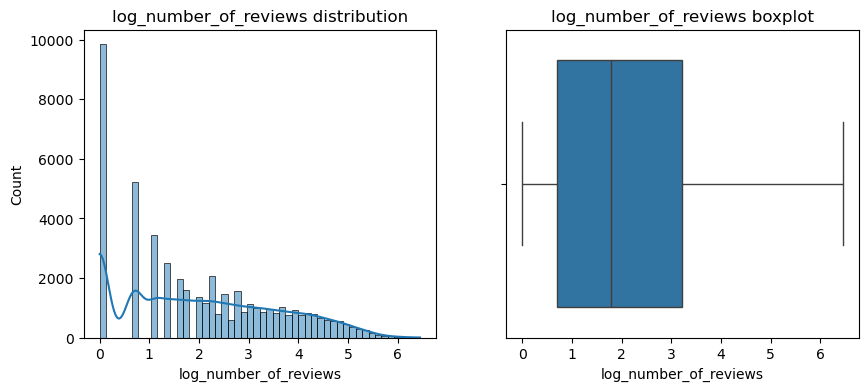

In [15]:
#log_number_of_reviews
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sns.histplot(df['log_number_of_reviews'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('log_number_of_reviews distribution')

sns.boxplot(x=df['log_number_of_reviews'], ax=axes[1])
axes[1].set_title('log_number_of_reviews boxplot')

plt.show()

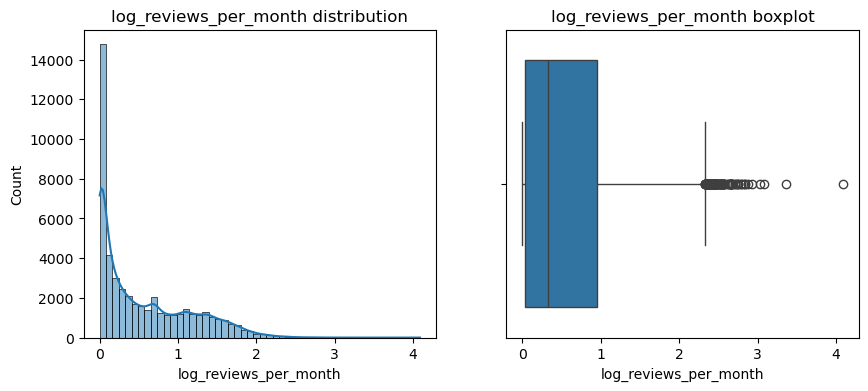

In [16]:
#log_reviews_per_month
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sns.histplot(df['log_reviews_per_month'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('log_reviews_per_month distribution')

sns.boxplot(x=df['log_reviews_per_month'], ax=axes[1])
axes[1].set_title('log_reviews_per_month boxplot')

plt.show()

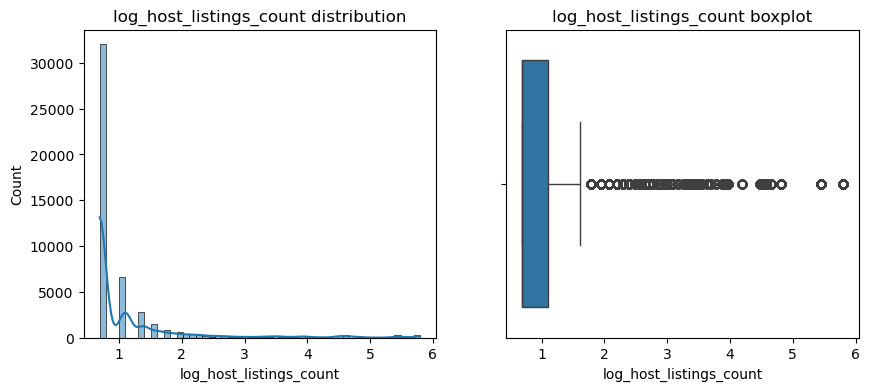

In [17]:
#log_host_listings_count
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sns.histplot(df['log_host_listings_count'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('log_host_listings_count distribution')

sns.boxplot(x=df['log_host_listings_count'], ax=axes[1])
axes[1].set_title('log_host_listings_count boxplot')

plt.show()

### Numerical variables analysis
The distributions of key numerical variables were previously skewed and included extreme outliers. After applying log transformations and capping where appropriate, the updated visualizations show significant improvement in symmetry and interpretability:

- `log_price`: The distribution is now approximately normal, with most listings centered around a log price of ~4.7 (which corresponds to ~$110 in actual price). Some outliers remain on both tails, but the transformation successfully compressed extreme price values.

- `minimum_nights_capped`: The cap at 50 nights reduced the influence of rare long-term listings. The distribution remains right-skewed but better reflects typical short-term stay behavior, with most values under 10 nights.

- `log_number_of_reviews`: The log transformation compressed the long right tail of review counts. Most listings now fall within a manageable range, with a concentration near 0 to 1.8 (~6 reviews).

- `log_reviews_per_month`: The transformation reduced the skewness highlighting a common range of 0–1.1 monthly reviews.

- `log_host_listings_count`: The transformation reveals that most hosts manage just 1–2 listings, with a few managing significantly more. The distribution is still right-skewed with high amount of outliers.


neighbourhood_group
Manhattan        21386
Brooklyn         19997
Queens            5650
Bronx             1088
Staten Island      370
Name: count, dtype: int64


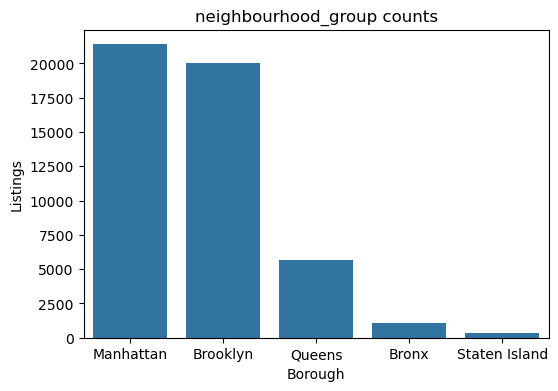

room_type
Entire home/apt    25102
Private room       22233
Shared room         1156
Name: count, dtype: int64


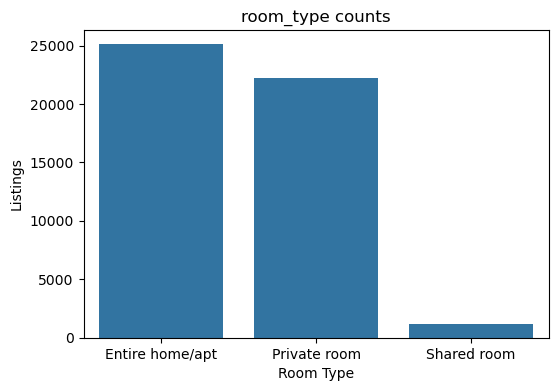

221
neighbourhood
Williamsburg          3897
Bedford-Stuyvesant    3699
Harlem                2644
Bushwick              2461
Hell's Kitchen        1946
Upper West Side       1941
East Village          1836
Upper East Side       1781
Crown Heights         1557
Midtown               1515
Greenpoint            1113
East Harlem           1107
Chelsea               1086
Lower East Side        907
Astoria                896
Washington Heights     891
West Village           751
Financial District     737
Flatbush               619
Clinton Hill           567
Name: count, dtype: int64


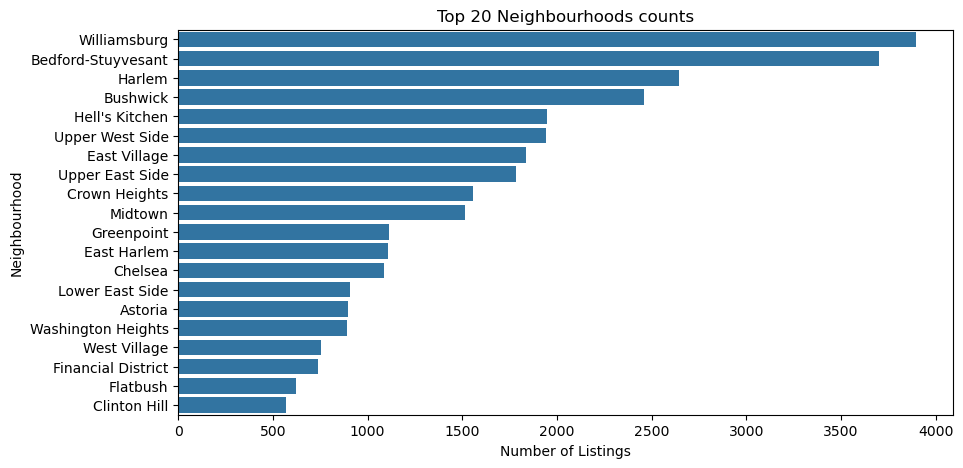

In [18]:
#Categorical variables analysis
print(df['neighbourhood_group'].value_counts())

# neighbourhood_group
plt.figure(figsize=(6, 4))
sns.countplot(x='neighbourhood_group', data=df, order=df['neighbourhood_group'].value_counts().index)
plt.title('neighbourhood_group counts')
plt.xlabel('Borough')
plt.ylabel('Listings')
plt.show()


#room_type
print(df['room_type'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='room_type', data=df, order=df['room_type'].value_counts().index)
plt.title('room_type counts')
plt.xlabel('Room Type')
plt.ylabel('Listings')
plt.show()


# neighbourhood
print(df['neighbourhood'].nunique())

# since there are too many neighborhoods (221), filtering only top 20
top_neigh = df['neighbourhood'].value_counts().nlargest(20)
print(top_neigh)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_neigh.values, y=top_neigh.index, orient='h')
plt.title('Top 20 Neighbourhoods counts')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')
plt.show()

### Catergorical variables analysis

The dataset contains several important categorical variables that may influence price and availability. Here's a summary of their distributions:

- `neighbourhood_group`: Listings are heavily concentrated in **Manhattan** and**Brooklyn**. Queens follows distantly, while the Bronx and Staten Island have very low representation.

- `room_type`: The most common type of listing is **Entire home/apt** , followed closely by **Private room**. **Shared rooms** are rare. This distribution suggests a strong lean toward more private, full-space accommodations.

- `neighbourhood`: There are 221 unique neighborhoods. The top 20 neighborhoods include **Williamsburg**, **Bedford-Stuyvesant**, **Harlem**, and **Bushwick** — each with over 2,000 listings. These neighborhoods may be highly active Airbnb markets and should be considered in modeling or segmentation.

The skewed distributions and dominance of a few categories in each variable highlight the need to be selective with encoding strategies.

## 5. Bivariate Analysis

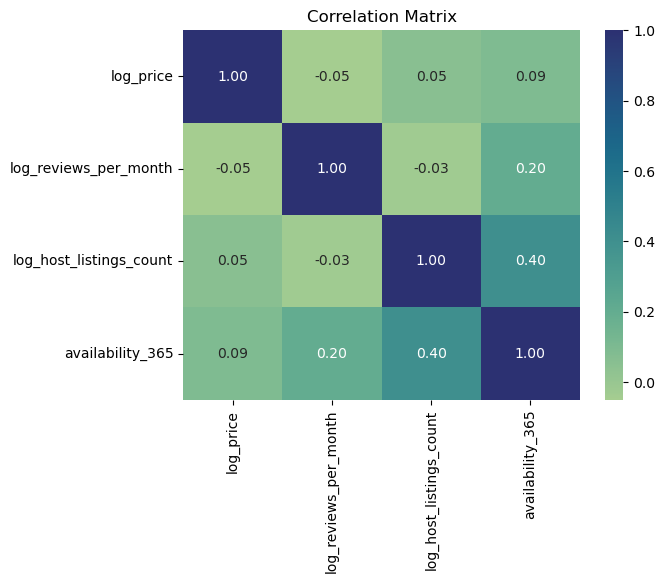

In [19]:
# Correlation matrix vetween log_price and other numerical variables.
vars = ['log_price', 'log_reviews_per_month', 'log_host_listings_count', 'availability_365']
corr_matrix = df[vars].corr()

sns.heatmap(corr_matrix, annot=True, cmap='crest', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### log_price vs numerical vars
The correlation matrix shows Pearson correlation coefficients between `log_price` and three selected predictors:

- `availability_365` shows the strongest positive correlation with `log_price` at 0.09, though still weak. This suggests that listings available more days per year may be priced slightly higher.

- `log_host_listings_count` has a very mild positive correlation (0.05), possibly indicating that commercial hosts price their listings marginally higher.

- `log_reviews_per_month` has a slightly negative correlation with `log_price` (-0.05), suggesting that listings with more frequent reviews tend to be modestly cheaper — possibly due to higher booking turnover or affordability.

Overall, none of the predictors are strongly linearly correlated with `log_price`.

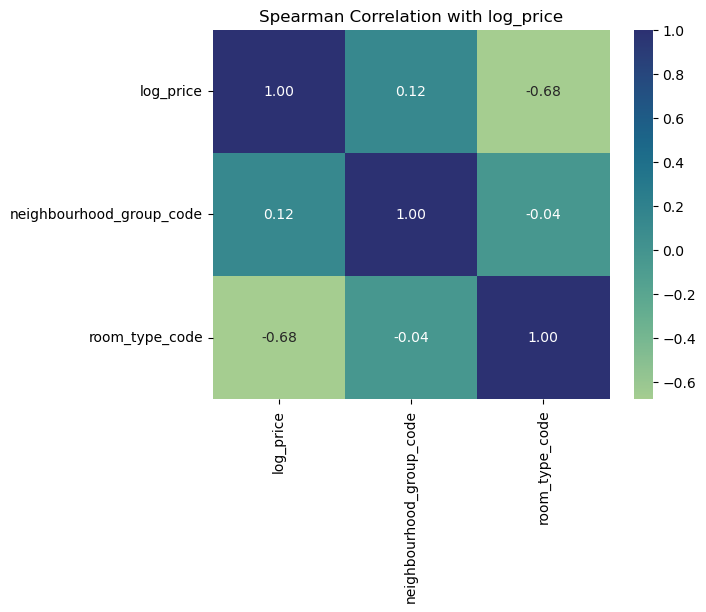

In [20]:
# convert categorical variables to categoty type
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
df['room_type'] = df['room_type'].astype('category')

# copy original dataframe to avoid changing original
df_encoded = df.copy()

# Convert categorical variables to numeric codes
df_encoded['neighbourhood_group_code'] = df_encoded['neighbourhood_group'].cat.codes
df_encoded['room_type_code'] = df_encoded['room_type'].cat.codes

# Compute Spearman correlation
spearman_corr = df_encoded[['log_price', 'neighbourhood_group_code', 'room_type_code']].corr(method='spearman')
spearman_corr

sns.heatmap(spearman_corr, annot=True, cmap='crest', fmt=".2f")
plt.title('Spearman Correlation with log_price')
plt.show()

### log_price vs categorical vars
To assess the relationship between key categorical variables and `log_price`, I computed Spearman rank correlation after encoding the categories numerically.

- `room_type_code` shows a strong negative correlation with `log_price` (-0.68). This makes sense given the encoded order:  
  - Entire home/apt (0),  
  - Private room (1),  
  - Shared room (2)  
  As the room type becomes more communal (higher code), the price decreases.

- `neighbourhood_group_code` has a weak positive correlation (0.12) with `log_price`. This suggests that boroughs assigned a higher code tend to have slightly lower prices, but the relationship is not strong.

These results confirm that room type is a strong categorical predictor of listing price, while neighbourhood group may still carry explanatory value, though to a lesser degree.

## 6. Test Statistics

### Hypothesis

I hypothesize that the room type significantly affects the average price of an Airbnb listing in New York City.

- **Null Hypothesis**:  
  The mean `log_price` is equal across all room types.
- **Alternative Hypothesis**:  
  At least one room type has a different mean `log_price`.

I will apply a **one-way ANOVA** to test whether `log_price` differs significantly across the three room types (`Entire home/apt`, `Private room`, `Shared room`).

The one-way ANOVA relies on the following assumptions:

- **Independence of observations**
   Each listing belongs to only one room type.

- **Normality of residuals within each group**  
   The response variable `log_price` has been log-transformed to address skewness.

- **Homogeneity of variances** 
   There may be differences in variance across room types. We will check this using **Levene’s Test** and consider robust alternatives if needed.

Despite some variance differences, ANOVA is considered reasonably robust for large, balanced samples like this dataset.

In [21]:
#import anova one way and levene's test
from scipy.stats import f_oneway, levene

In [22]:
# grouping data
entire = df[df['room_type'] == 'Entire home/apt']['log_price']
private = df[df['room_type'] == 'Private room']['log_price']
shared = df[df['room_type'] == 'Shared room']['log_price']

# ANOVA test
f_stat, p_value = f_oneway(entire, private, shared)

# Levene's test for variance equality
lev_stat, lev_p = levene(entire, private, shared)

print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_value)
print("Levene's p-value:", lev_p)

ANOVA F-statistic: 16596.083176750002
ANOVA p-value: 0.0
Levene's p-value: 3.817649179166037e-51


### One-way ANOVA evaluation
The one-way ANOVA comparing `log_price` across the three room types output:

- **F-statistic**: 16596.08  
- **P-value**: < 0.0001

The p-value is far below the 0.05 significance threshold, so we can reject the null hypothesis.

This result indicates that there is a statistically significant difference in average Airbnb price between `Entire home/apt` and `Private room` listings. Specifically, listings categorized as entire homes tend to have higher prices than private rooms, even after log transformation.

This supports our hypothesis that room type has a meaningful effect on listing price.


To assess the assumption of equal variances, I conducted **Levene’s test**:

- **Levene’s p-value**: 3.82e-51

This extremely small p-value suggests a violation of the homogeneity of variance assumption, meaning the room types do not have equal variances in `log_price`.

Even though the traditional ANOVA result is statistically significant, the unequal variances mean that **Welch’s ANOVA** would be better.

Welch's ANOVA is a variation of one-way ANOVA that is designed to handle violations of the equal variance assumption.


In [23]:
#import welch's anova
import pingouin as pg

In [24]:
#perform welch's anova
welch = pg.welch_anova(dv='log_price', between='room_type', data=df)
print(welch)

      Source  ddof1        ddof2             F  p-unc       np2
0  room_type      2  3093.142488  16398.223966    0.0  0.406368


### Welch's ANOVA evaluation
The results for Welch's ANOVA were:
- **F-statistic**: 16,398.22  
- **Degrees of freedom**: Between groups = 2, Within groups = 3093.14  
- **P-value**: < 0.0001  
- **Effect size**: 0.406

Since the p-value is well below the 0.05 significance level, I can reject the null hypothesis.  
This confirms that at least one room type has a significantly different average `log_price`.

The effect size (0.406) indicates a large effect, meaning that room type accounts for a substantial proportion of the variance in listing prices.

Welch’s ANOVA confirms that room type significantly affects Airbnb listing price, even after accounting for unequal variances. This finding is consistent and robust across both standard and variance-corrected statistical tests.

## 7. Regression

In this section, I will build a multiple linear regression model to predict the log-transformed price (`log_price`) of Airbnb listings. The goal is to understand how various listing characteristics contribute to pricing.

I will use a combination of categorical and numerical predictors:
- `room_type` and `neighbourhood_group`
- `log_reviews_per_month`, `log_host_listings_count`, and `availability_365`

Dummy variables are created for the categorical predictors, and the model is fit using Ordinary Least Squares (OLS). I will evaluate the model using R², adjusted R², and p-values to assess significance and fit quality.

In [25]:
#import regression functions
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [26]:
#predictors and target
predictors = ['room_type', 'neighbourhood_group', 
              'log_reviews_per_month', 'log_host_listings_count', 'availability_365']
df_model = df[predictors + ['log_price']].copy()

#dummy variables for categorical
df_model = pd.get_dummies(df_model, columns=['room_type', 'neighbourhood_group'], drop_first=True)

#separate X and y
X = df_model.drop(columns='log_price')
y = df_model['log_price']

#split data train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#fit regression model
model = LinearRegression()
model.fit(X_train, y_train)

#evaluate model
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", round(r2, 3))
print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))

#get model coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)
                          

R2 Score: 0.48
RMSE: 0.485
MAE: 0.36
                             Feature  Coefficient
6      neighbourhood_group_Manhattan     0.546155
5       neighbourhood_group_Brooklyn     0.231944
7         neighbourhood_group_Queens     0.111850
8  neighbourhood_group_Staten Island     0.005469
2                   availability_365     0.000682
1            log_host_listings_count    -0.023471
0              log_reviews_per_month    -0.049703
3             room_type_Private room    -0.764602
4              room_type_Shared room    -1.157288


### Evaluation
The multiple linear regression model was trained to predict `log_price` using a mix of categorical and numerical predictors. Model performance was:

- **R2 Score**: 0.48  
  About 48% of the variation in `log_price` is explained by the model.

- **RMSE**: 0.485  
  The model's average prediction error is roughly 0.485 log units, which is moderate pricing error on the original price scale.

- **MAE**: 0.36  
  The average absolute error is about 0.36 log units.

Coefficient interpretations:
- `room_type`
  - Private rooms are priced 0.76 log units lower than entire apartments.
  - Shared rooms are even lower at 1.16 log units less.
  - This confirms that room type is a major driver of price differences

- `neighbourhood_group`
  - Manhattan listings are priced the highest.
  - Other boroughs (Brooklyn, Queens) also positively affect price compared to the dropped reference category.

- Numeric variables
  - `log_reviews_per_month` and `log_host_listings_count` have small negative effects, suggesting higher review activity or host volume may be associated with slightly lower pricing.
  - `availability_365` has a minimal positive impact.

The model confirms that room type and location are the most influential factors affecting price, while review and availability metrics play a more subtle role. The model has moderate explanatory power (R2 = 0.48), leaving room for further improvement using more granular features.

## 8. Classification

In this section, I will build a classification model to predict the type of room (`room_type`) offered in an Airbnb listing. The target variable has three classes: `Entire home/apt`, `Private room`, and `Shared room`.

I will use a **Decision Tree Classifier**.

The model uses the following predictors:
- `neighbourhood_group`
- `log_reviews_per_month`
- `log_host_listings_count`
- `availability_365`

Model performance will be evaluated using accuracy, precision, recall, and the confusion matrix.

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [28]:
#predictors and target
features = ['neighbourhood_group', 'log_reviews_per_month', 
            'log_host_listings_count', 'availability_365']
df_rt = df[features + ['room_type']].copy()

#dummy for categorical var
df_rt = pd.get_dummies(df_rt,columns=['neighbourhood_group'], drop_first=True)

#define X and y
X = df_rt.drop(columns='room_type')
y = df_rt['room_type']

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#train decision tree
clf = DecisionTreeClassifier(random_state=0, max_depth=5) 
clf.fit(X_train, y_train)

#evaluate the tree
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))

                 precision    recall  f1-score   support

Entire home/apt       0.65      0.71      0.68      4960
   Private room       0.63      0.59      0.61      4512
    Shared room       0.00      0.00      0.00       227

       accuracy                           0.64      9699
      macro avg       0.42      0.43      0.43      9699
   weighted avg       0.62      0.64      0.63      9699

[[3518 1442    0]
 [1840 2672    0]
 [  76  151    0]]


### Decision tree evaluation
The decision tree classifier was trained to predict `room_type` based on listing characteristics. Model performance was:

- **Overall Accuracy**: 64%
- **Weighted F1-score**: 0.63  
  Indicates decent balance between precision and recall across all classes

- `Entire home/apt`: Precision = 0.65, Recall = 0.71  
  The model performs best on this class, which is also the most common.
- `Private room`: Precision = 0.63, Recall = 0.59  
  Slightly lower performance, likely due to overlap with entire homes in some features.
- `Shared room`: Precision = 0.00, Recall = 0.00  
  The model failed to correctly predict any shared rooms.

The confusion matrix shows that:
- `Shared room` predictions are completely misclassified as other types.
- The model has no predictive power for this rare class.
- Most errors involve confusion between `Entire home/apt` and `Private room`.


The model performs reasonably well for the two dominant room types but fails to capture the minority class `Shared room`.

## 9. Clustering

In this section, I will apply **K-Means clustering** to identify natural groupings among Airbnb listings based on their pricing, review activity, and availability patterns.

Below continuous variables are inputs:
- `log_price`
- `log_reviews_per_month`
- `availability_365`

The elbow method is used to determine the optimal number of clusters.

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

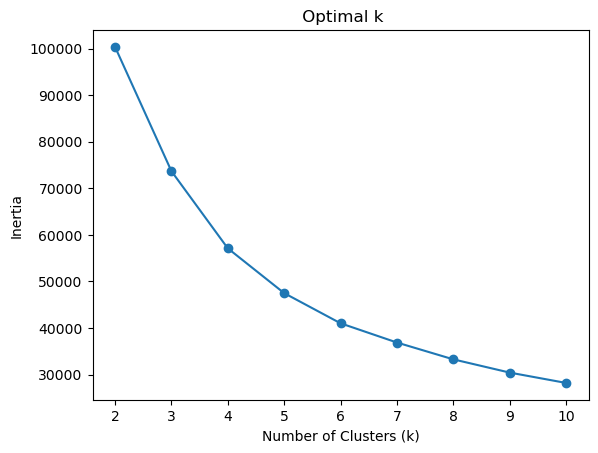

In [30]:
#variables
cluster_vars = ['log_price', 'log_reviews_per_month', 'availability_365']
df_cluster = df[cluster_vars].copy()

#scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

#using elbow method to find k
inertia = []
k_range = range(2, 11)

#loop thru and cluster by k and record inertia
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title(' Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

According to the elbox plot, the elbow point is at k = 4, where the inertia begins to level off.
Now, I will use k = 4 for the model.

         log_price  log_reviews_per_month  availability_365
cluster                                                    
0             4.19                   0.24             25.86
1             4.87                   0.40            309.06
2             5.29                   0.25             28.37
3             4.63                   1.44            138.08


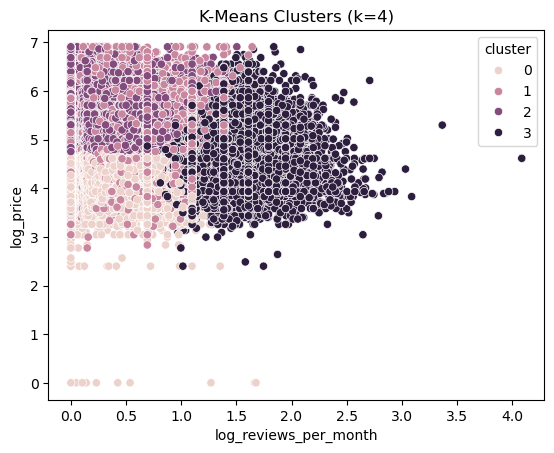

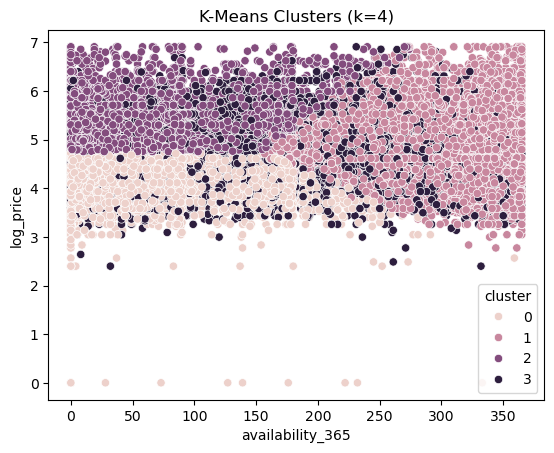

In [31]:
# fit k means model
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df_cluster.groupby('cluster').mean().round(2)
print(cluster_summary)

sns.scatterplot(x='log_reviews_per_month', y='log_price', hue='cluster', data=df_cluster)
plt.title('K-Means Clusters (k=4)')
plt.show()

sns.scatterplot(x='availability_365', y='log_price', hue='cluster', data=df_cluster)
plt.title('K-Means Clusters (k=4)')
plt.show()

### clustering evaluation

Using k = 4, Airbnb listings are clustered based on three continous variables. The clusters represent distinct segments in terms of pricing, availability, and review activity.

#### cluster summary:
- Cluster 0: Low price, low review activity, low availability  

- Cluster 1: Mid-range price, mild activity, high availability  
  listings with moderate pricing

- Cluster 2: High price, low availability, low activity  
  Likely premium or luxury listings with selective availability

- Cluster 3: Moderate price, very high activity, mid-range availability  
  Highly active listings, possibly popular among repeat guests

#### plots summary:
- log_price vs. log_reviews_per_month
    - Cluster 3 dominates the high-review region, suggesting this group consists of active, moderately priced listings.
    - Cluster 0, 1, and 2 are in the low review activity region
- log_price vs. availability_365:
    - Cluster 1 stretches across a wide availability range but maintains mid-range pricing.
    - Cluster 0 is concentrated on the low-price, low-availability end, while Cluster 2 is higher priced but low availability.

These clusters provide a strong evidence for market segmentation, targeted pricing strategies, or filtering listings based on usage patterns.

## 10. Machine Learning

### Random forest regression
To enhance the performance and capture potential nonlinear relationships missed by linear regression, I will apply a **Random Forest Regressor** to model `log_price`.

Random Forest is an ensemble learning method that builds multiple decision trees and averages their predictions:
- Robust to outliers and non-normal distributions
- Capable of modeling complex feature interactions
- Non-parametric with no assumptions about linearity

I am using the same set of predictors as the base regression model.
The model will be evaluated on the test set using R2, RMSE, and MAE, allowing a direct comparison to the previous linear regression results.

In [32]:
from sklearn.ensemble import RandomForestRegressor

In [33]:
#set predictors and copy original df
predictors = ['room_type', 'neighbourhood_group', 'log_reviews_per_month', 'log_host_listings_count', 'availability_365']
df_rf = df[predictors + ['log_price']].copy()

#dummy for catergorical data
df_rf = pd.get_dummies(df_rf, columns=['room_type', 'neighbourhood_group'], drop_first=True)

X = df_rf.drop(columns='log_price')
y = df_rf['log_price']

#test split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#fitting random forest regression model
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)


#evaluation of the model
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest R²:", round(r2_rf, 3))
print("Random Forest RMSE:", round(rmse_rf, 3))
print("Random Forest MAE:", round(mae_rf, 3))

Random Forest R²: 0.468
Random Forest RMSE: 0.491
Random Forest MAE: 0.363


### Random forest model results

The Random Forest model was trained on the same feature set used in linear regression. Model performance was:
- R2: 0.468  
- RMSE: 0.491  
- MAE: 0.363

where the linear regression model performance was:
- R2: 0.480
- RMSE: 0.485
- MAE: 0.360

Although Random Forest is capable of capturing nonlinear relationships, it did not outperform the linear regression model in this case. Both models showed similar performance, with the linear model having a slight edge in R2 and RMSE.
Given that Random Forest introduces more complexity and computation cost, the linear regression model remains the preferred approach for this dataset based on simplicity and slightly better predictive accuracy. However, Random Forest is still useful for capturing interactions or nonlinearities that may become more evident with richer feature sets.

## 11. Conclusion

This project conducted a full exploratory and predictive analysis of New York City Airbnb data, focusing on understanding the factors that influence listing price and behavior.

#### Key findings:
- EDA revealed that `room_type` and `neighbourhood_group` are the strongest categorical indicators of price, while `log_reviews_per_month` and `availability_365` provide additional explanatory value.
- Hypothesis testing with Welch’s ANOVA confirmed that room type has a statistically significant impact on `log_price`, with large effect size.
- Linear Regression explained ~48% of the variation in log-transformed price, with interpretable coefficients showing strong effects for room type and borough.
- Classification with Decision Tree achieved 64% accuracy in predicting room type, though performance was limited by the underrepresentation of "Shared room".
- K-Means Clustering segmented listings into four meaningful groups based on price, availability, and activity, helping identify distinct rental behavior patterns.
- Random Forest Regression did not significantly outperform the linear model, reaffirming that simple models may be more effective when feature relationships are mostly linear.